In [4]:
import pandas as pd
import matplotlib.pyplot as plt

deals_df = pd.read_csv("clear_deals.csv")
projects_df = pd.read_csv("clear_projects.csv")

deals_df = deals_df[deals_df["тип_лота"] == "квартира"]
projects_df = projects_df[projects_df["тип_объекта_недвижимости"] == "квартира"]

In [25]:
import matplotlib.pyplot as plt

def apply_dark_yellow_style():
    plt.style.use('dark_background')

apply_dark_yellow_style()

,id_корпуса,стадия_строительства,девелопер,building_floors_count,total_flats_in_building,плановая_дата_рвэ,floor,deals_count_x,sales_share,sales_share_group,...,avg_price_per_sqm,avg_floor_area_A,total_project_area,avg_floor_area_B,developer_total_buildings,median_days_to_sale,mean_days_to_sale,deals_count_y,mortgage_share,район
0,0081bc4d4059f46b3b42276ba8aee782,Введен в эксплуатацию,Абсолют Недвижимость,17,549,2025-08-21,522.314286,312,0.568306,Ниже_медианы,...,211137.297571,28983.210200,348500.60,20500.035294,24,513.0,512.467949,312,0.804487,Внуково
1,013e43142be6303646e81ccd28432986,Введен в эксплуатацию,А101,17,185,2025-06-17,100.187059,154,0.832432,Выше_или_равно_медианы,...,230538.094875,8607.963784,22657.90,1332.817647,176,305.0,362.045455,154,0.772727,Коммунарка
2,059550c08c9b9a9f1a38d43293930e67,Введен в эксплуатацию,Самолет,10,101,2025-04-11,120.191316,53,0.524752,Ниже_медианы,...,194094.698758,4522.049505,15439.65,1543.965000,93,608.0,619.792453,53,0.867925,Внуково
3,08810b5305ca2c2da6e9e1aa5db0174b,Введен в эксплуатацию,Самолет,13,494,2024-11-12,473.454038,365,0.738866,Выше_или_равно_медианы,...,206479.621843,24619.610000,285192.69,21937.899231,93,464.0,479.624658,365,0.928767,Щербинка
4,0cf1f9c7f125467ce3cc55ebdebebdff,Введен в эксплуатацию,А101,7,77,2025-09-24,133.160714,67,0.870130,Выше_или_равно_медианы,...,215736.937259,3728.500000,10866.20,1552.314286,176,130.0,188.955224,67,0.955224,Коммунарка
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,f5fd178be7b9fcfafa73a52df8c4696f,Введен в эксплуатацию,Абсолют Недвижимость,12,298,2024-08-28,585.953125,99,0.332215,Ниже_медианы,...,253922.372532,18876.342282,217211.40,18100.950000,24,514.0,508.565657,99,0.868687,Внуково
113,f88eb31294efa9ae4e42d6eea84414cc,Введен в эксплуатацию,А101,15,128,2025-07-30,82.657333,118,0.921875,Выше_или_равно_медианы,...,265378.060341,6538.324219,13311.00,887.400000,176,334.0,342.567797,118,0.855932,Коммунарка
114,fc7dbe2d2ed10547d097316bf6a10e3b,Введен в эксплуатацию,А101,17,185,2025-05-30,123.395652,158,0.854054,Выше_или_равно_медианы,...,225271.493152,8606.346486,24774.10,1457.300000,176,339.0,379.284810,158,0.867089,Коммунарка
115,fde1f8ad4322f757d44bdf4c634df283,Введен в эксплуатацию,А101,17,185,2025-05-30,121.002857,153,0.827027,Выше_или_равно_медианы,...,250383.975641,8561.769730,26564.10,1562.594118,176,356.0,356.496732,153,0.908497,Коммунарка


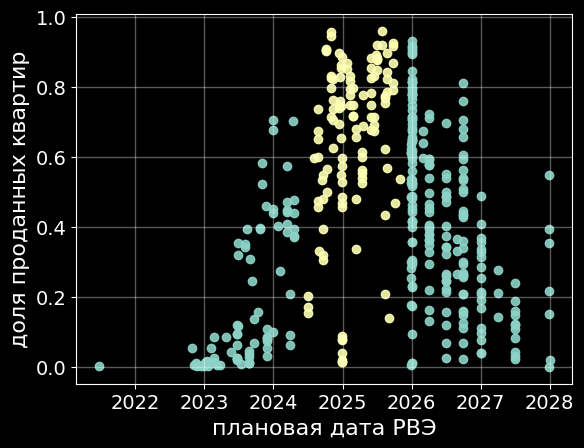

In [71]:
projects_buildings_df = (
    projects_df[projects_df["тип_объекта_недвижимости"] == "квартира"]
    .groupby("id_корпуса")
    .agg(
        # стадия строительства корпус
        стадия_строительства=("стадия_строительства", "first"),

        девелопер=("девелопер", "first"),

        # этажность дома
        building_floors_count=("этаж", "nunique"),

        # общее количество квартир в корпусе
        total_flats_in_building=("количество_лотов", "sum"),

        плановая_дата_рвэ=("плановая_дата_рвэ", "first"),

        floor=("общая_проектная_площадь", "mean")
    )
    .reset_index()
)

deals_count_by_building_df = (
    deals_df[deals_df["тип_лота"] == "квартира"]
    .groupby("id_корпуса")
    .size()
    .reset_index(name="deals_count")
)

deals_count_by_building_df.head()

projects_buildings_df = projects_buildings_df.merge(
    deals_count_by_building_df,
    on="id_корпуса",
    how="left"
)

# если по корпусу не было сделок
projects_buildings_df["deals_count"] = (
    projects_buildings_df["deals_count"]
    .fillna(0)
    .astype(int)
)

projects_buildings_df["плановая_дата_рвэ"] = pd.to_datetime(
    projects_buildings_df["плановая_дата_рвэ"],
    errors="coerce"
)

start_date = pd.Timestamp("2024-07-01")  # середина 2024

buildings_group_df = projects_buildings_df.copy()

buildings_group_df["sales_share"] = (
    buildings_group_df["deals_count"]
    / buildings_group_df["total_flats_in_building"]
)

# границы дат
end_date = pd.Timestamp("2025-11-30")

mask_2024_2026 = (
    (buildings_group_df["плановая_дата_рвэ"] >= start_date) &
    (buildings_group_df["плановая_дата_рвэ"] < end_date)
)

# остальные корпуса
plt.scatter(
    buildings_group_df.loc[~mask_2024_2026, "плановая_дата_рвэ"],
    buildings_group_df.loc[~mask_2024_2026, "sales_share"],
    alpha=0.9,
    label="Остальные корпуса"
)

# выделенные корпуса
plt.scatter(
    buildings_group_df.loc[mask_2024_2026, "плановая_дата_рвэ"],
    buildings_group_df.loc[mask_2024_2026, "sales_share"],
    alpha=0.9,
    label="РВЭ: II пол. 2024 – 2025"
)

buildings_group_df = buildings_group_df[
    (projects_buildings_df["стадия_строительства"] == "Введен в эксплуатацию") &
    (projects_buildings_df["плановая_дата_рвэ"] > start_date)
]

median_sales_share = buildings_group_df["sales_share"].median()

buildings_group_df["sales_share_group"] = (
    buildings_group_df["sales_share"] >= median_sales_share
).map({
    True: "Выше_или_равно_медианы",
    False: "Ниже_медианы"
})

buildings_group_df["flats_per_floor"] = (
    buildings_group_df["total_flats_in_building"]
    / buildings_group_df["building_floors_count"]
).round()
buildings_group_df["flats_per_floor"]

project_area_agg = (
    projects_df
    .groupby("id_корпуса")
    .agg(
        total_project_area=("общая_проектная_площадь", "sum"),
        total_lots=("количество_лотов", "sum")
    )
    .reset_index()
)

project_area_agg["avg_flat_area"] = (
    project_area_agg["total_project_area"]
    / project_area_agg["total_lots"]
)

project_area_agg

price_agg = (
    deals_df
    .groupby("id_корпуса")
    .agg(
        total_deal_area=("площадь_объекта", "sum"),
        total_deal_budget=("реальная_сумма_бюджета", "sum"),
        deals_count=("id_корпуса", "count")
    )
    .reset_index()
)

price_agg["avg_price_per_sqm"] = (
    price_agg["total_deal_budget"]
    / price_agg["total_deal_area"]
)

buildings_group_df = (
    buildings_group_df
    .merge(
        project_area_agg[["id_корпуса", "avg_flat_area"]],
        on="id_корпуса",
        how="left"
    )
    .merge(
        price_agg[["id_корпуса", "avg_price_per_sqm"]],
        on="id_корпуса",
        how="left"
    )
)

# ПЛОЩАДЬ НА ЭТАЖ

buildings_group_df["avg_floor_area_A"] = (
    buildings_group_df["avg_flat_area"]
    * buildings_group_df["flats_per_floor"] * buildings_group_df["building_floors_count"]
)

projects_df["project_area_row_sum"] = (
    projects_df["общая_проектная_площадь"]
    * projects_df["количество_лотов"]
)

total_project_area_by_building = (
    projects_df
    .groupby("id_корпуса", as_index=False)
    .agg(
        total_project_area=("project_area_row_sum", "sum")
    )
)

buildings_group_df = buildings_group_df.merge(
    total_project_area_by_building,
    on="id_корпуса",
    how="left"
)

buildings_group_df["avg_floor_area_B"] = (
    buildings_group_df["total_project_area"]
    / buildings_group_df["building_floors_count"]
)

# девелопер

developer_buildings_count = (
    projects_df
    .groupby("девелопер", as_index=False)
    .agg(
        developer_total_buildings=("id_корпуса", "nunique")
    )
)
median_devs = developer_buildings_count["developer_total_buildings"].mean()

buildings_group_df = buildings_group_df.merge(
    developer_buildings_count,
    on="девелопер",
    how="left"
)

# "скорость от начала продаж средняя"

deals_df["deal_date"] = pd.to_datetime(
    deals_df["дата_регистрации_(месяц.год)"],
    errors="coerce"
)

deals_df["start_sales_date"] = pd.to_datetime(
    deals_df["дата_начала_продаж"],
    errors="coerce"
)

deals_df["days_to_sale"] = (
    deals_df["deal_date"] - deals_df["start_sales_date"]
).dt.days

deals_df = deals_df[
    (deals_df["days_to_sale"] >= 0) &
    (deals_df["days_to_sale"].notna())
]

sales_speed_by_building = (
    deals_df
    .groupby("id_корпуса", as_index=False)
    .agg(
        median_days_to_sale=("days_to_sale", "median"),
        mean_days_to_sale=("days_to_sale", "mean"),
        deals_count=("days_to_sale", "count")
    )
)

buildings_group_df = buildings_group_df.merge(
    sales_speed_by_building,
    on="id_корпуса",
    how="left"
)

mortgage_share_by_building = (
    deals_df
    .groupby("id_корпуса")["ипотека"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reset_index()
)
mortgage_share_by_building = mortgage_share_by_building.rename(
    columns={
        "Ипотека": "mortgage_share",
        "Нет": "no_mortgage_share"
    }
)
mortgage_share_by_building = mortgage_share_by_building.drop(
    columns=["no_mortgage_share"]
)
buildings_group_df = buildings_group_df.merge(
    mortgage_share_by_building,
    on="id_корпуса",
    how="left"
)

district_by_building = (
    deals_df
    .groupby("id_корпуса", as_index=False)
    .agg(
        район=("район", "first")
    )
)

buildings_group_df = buildings_group_df.merge(
    district_by_building,
    on="id_корпуса",
    how="left"
)

plt.ylabel("доля проданных квартир")
plt.xlabel("плановая дата РВЭ")

buildings_group_df

(array([ 7.,  3.,  2.,  4., 10., 12., 11., 23., 25., 20.]),
 array([0.01276596, 0.10758311, 0.20240027, 0.29721742, 0.39203457,
        0.48685173, 0.58166888, 0.67648604, 0.77130319, 0.86612035,
        0.9609375 ]),
 <BarContainer object of 10 artists>)

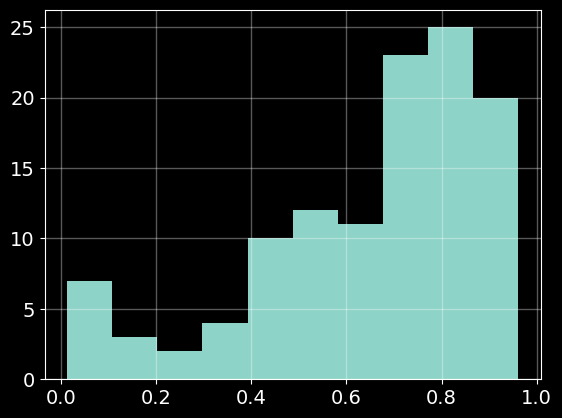

In [ ]:
plt.hist(buildings_group_df["sales_share"])

                            OLS Regression Results                            
Dep. Variable:            sales_share   R-squared:                       0.242
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     36.67
Date:                Mon, 15 Dec 2025   Prob (F-statistic):           1.81e-08
Time:                        17:50:22   Log-Likelihood:                 16.292
No. Observations:                 117   AIC:                            -28.58
Df Residuals:                     115   BIC:                            -23.06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

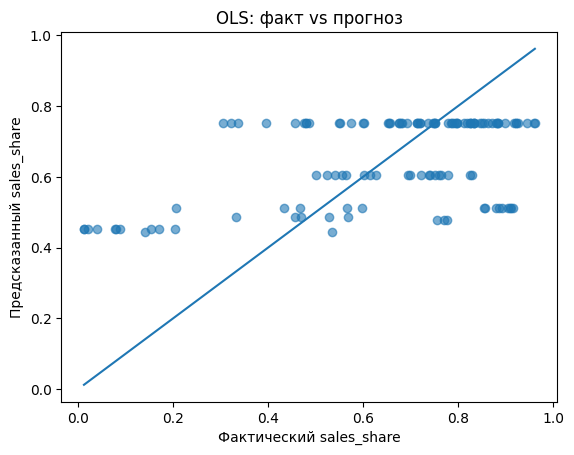

"developer_total_buildings"
t-statistic: -2.846
p-value: 0.0053
Mean (Ниже медианы): 100.0
Mean (Выше медианы): 135.2
____________


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

features = [
    "avg_price_per_sqm",
    "developer_total_buildings"
]

df_reg = buildings_group_df[features + ["sales_share"]].copy()

# приведение к numeric
for c in features + ["sales_share"]:
    df_reg[c] = pd.to_numeric(df_reg[c], errors="coerce")

# чистка
df_reg = (
    df_reg
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(df_reg[features])
y = df_reg["sales_share"]

model = sm.OLS(y, X).fit()

print(model.summary())
print(f"R² = {model.rsquared:.3f}")
print(f"Adj. R² = {model.rsquared_adj:.3f}")

y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred, alpha=0.6)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Фактический sales_share")
plt.ylabel("Предсказанный sales_share")
plt.title("OLS: факт vs прогноз")
plt.show()

for cat in features:
    print(f'"{cat}"')
    low_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Ниже_медианы",
        cat
    ]

    high_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Выше_или_равно_медианы",
        cat
    ]

    t_stat, p_value = stats.ttest_ind(
        low_group,
        high_group,
        equal_var=False
    )

    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

    print(f"Mean (Ниже медианы): {low_group.mean():.1f}")
    print(f"Mean (Выше медианы): {high_group.mean():.1f}")
    print("____________")

Коэффициент наклона (β1): 0.0017
Свободный член (β0): 0.4432
R²: 0.242


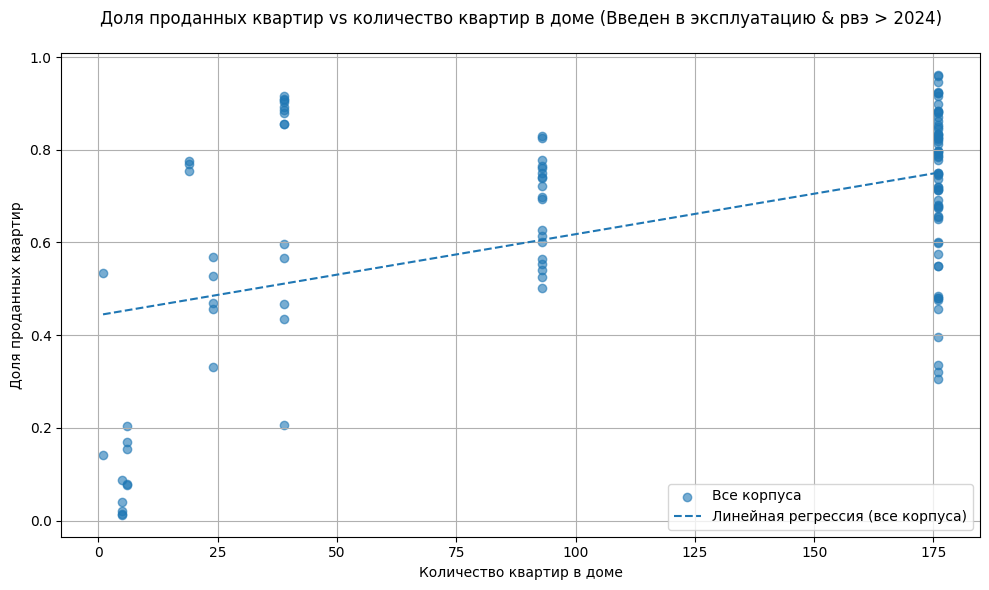

In [112]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = buildings_group_df["developer_total_buildings"].values.reshape(-1, 1)
y = buildings_group_df["sales_share"].values

model_all = LinearRegression()
model_all.fit(X, y)

x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model_all.predict(x_line)

print(f"Коэффициент наклона (β1): {model_all.coef_[0]:.4f}")
print(f"Свободный член (β0): {model_all.intercept_:.4f}")
print(f"R²: {model_all.score(X, y):.3f}")

plt.figure(figsize=(10, 6))

plt.scatter(
    buildings_group_df["developer_total_buildings"],
    buildings_group_df["sales_share"],
    alpha=0.6,
    label="Все корпуса"
)

plt.plot(
    x_line,
    y_line,
    linestyle="--",
    label="Линейная регрессия (все корпуса)"
)

plt.xlabel("Количество квартир в доме")
plt.ylabel("Доля проданных квартир")
plt.title("Доля проданных квартир vs количество квартир в доме (Введен в эксплуатацию & рвэ > 2024)\n")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [113]:
from scipy import stats

categories = [
    "total_flats_in_building",
    "building_floors_count",
    "avg_flat_area",
    "flats_per_floor",
    "avg_price_per_sqm",
    "avg_floor_area_B",
    "developer_total_buildings"
]

for cat in categories:
    print(f'"{cat}"')
    low_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Ниже_медианы",
        cat
    ]

    high_group = buildings_group_df.loc[
        buildings_group_df["sales_share_group"] == "Выше_или_равно_медианы",
        cat
    ]

    t_stat, p_value = stats.ttest_ind(
        low_group,
        high_group,
        equal_var=False
    )

    print(f"t-statistic: {t_stat:.3f}")
    print(f"p-value: {p_value:.4f}")

    print(f"Mean (Ниже медианы): {low_group.mean():.1f}")
    print(f"Mean (Выше медианы): {high_group.mean():.1f}")
    print("____________")

"total_flats_in_building"
t-statistic: 2.120
p-value: 0.0371
Mean (Ниже медианы): 325.4
Mean (Выше медианы): 228.0
____________
"building_floors_count"
t-statistic: 0.008
p-value: 0.9939
Mean (Ниже медианы): 13.8
Mean (Выше медианы): 13.8
____________
"avg_flat_area"
t-statistic: 1.226
p-value: 0.2229
Mean (Ниже медианы): 48.6
Mean (Выше медианы): 46.9
____________
"flats_per_floor"
t-statistic: 2.240
p-value: 0.0272
Mean (Ниже медианы): 23.5
Mean (Выше медианы): 17.4
____________
"avg_price_per_sqm"
t-statistic: -1.802
p-value: 0.0753
Mean (Ниже медианы): 217601.8
Mean (Выше медианы): 232770.8
____________
"avg_floor_area_B"
t-statistic: 1.849
p-value: 0.0679
Mean (Ниже медианы): 14960.6
Mean (Выше медианы): 8072.7
____________
"developer_total_buildings"
t-statistic: -2.846
p-value: 0.0053
Mean (Ниже медианы): 100.0
Mean (Выше медианы): 135.2
____________


                            OLS Regression Results                            
Dep. Variable:            sales_share   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.240
Method:                 Least Squares   F-statistic:                     10.18
Date:                Tue, 16 Dec 2025   Prob (F-statistic):           4.59e-07
Time:                        01:09:52   Log-Likelihood:                 18.388
No. Observations:                 117   AIC:                            -26.78
Df Residuals:                     112   BIC:                            -12.97
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

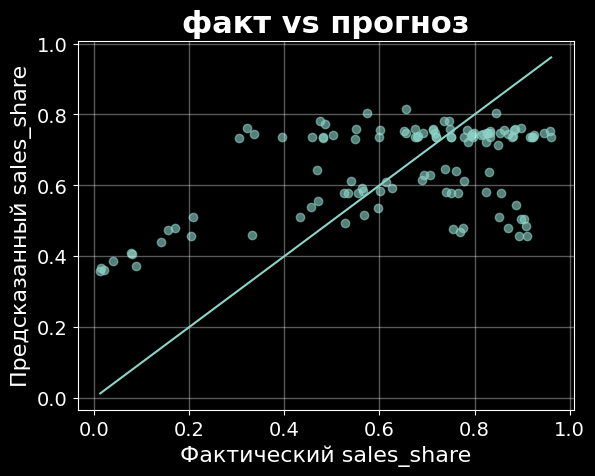

In [43]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

features = [
    "total_flats_in_building",
    "building_floors_count",
    "avg_floor_area_B",
    "developer_total_buildings"
]
df_reg = buildings_group_df[features + ["sales_share"]].copy()

# приведение к numeric
for c in features + ["sales_share"]:
    df_reg[c] = pd.to_numeric(df_reg[c], errors="coerce")

# чистка
df_reg = (
    df_reg
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(df_reg[features])
y = df_reg["sales_share"]

model = sm.OLS(y, X).fit()

print(model.summary())
print(f"R² = {model.rsquared:.3f}")
print(f"Adj. R² = {model.rsquared_adj:.3f}")

y_pred = model.predict(X)

plt.figure()
plt.scatter(y, y_pred, alpha=0.6)

min_val = min(y.min(), y_pred.min())
max_val = max(y.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Фактический sales_share")
plt.ylabel("Предсказанный sales_share")
plt.title("факт vs прогноз")
plt.show()

                                OLS Regression Results                               
Dep. Variable:     developer_total_buildings   R-squared:                       0.322
Model:                                   OLS   Adj. R-squared:                  0.316
Method:                        Least Squares   F-statistic:                     54.15
Date:                       Mon, 15 Dec 2025   Prob (F-statistic):           3.09e-11
Time:                               23:39:28   Log-Likelihood:                -630.63
No. Observations:                        116   AIC:                             1265.
Df Residuals:                            114   BIC:                             1271.
Df Model:                                  1                                         
Covariance Type:                   nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------

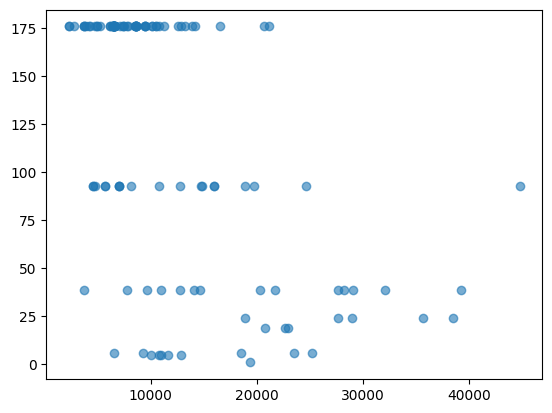

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

dff = buildings_group_df[buildings_group_df["avg_floor_area_A"] < 80000]

df_lr = dff[
    ["developer_total_buildings", "avg_floor_area_A"]
].copy()

# приведение к numeric + чистка
for c in df_lr.columns:
    df_lr[c] = pd.to_numeric(df_lr[c], errors="coerce")

df_lr = (
    df_lr
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

X = sm.add_constant(df_lr["avg_floor_area_A"])
y = df_lr["developer_total_buildings"]

model = sm.OLS(y, X).fit()

print(model.summary())
print(f"R² = {model.rsquared:.3f}")

# линия регрессии
x_sorted = df_lr["avg_floor_area_A"].sort_values()
y_line = model.predict(sm.add_constant(x_sorted))

plt.figure()
plt.scatter(
    df_lr["avg_floor_area_A"],
    df_lr["developer_total_buildings"],
    alpha=0.6
)

plt.show()


/var/folders/ws/lrvlpqj171xc51myg0jksgdr0000gn/T/ipykernel_17526/1067624138.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


<Figure size 800x800 with 0 Axes>

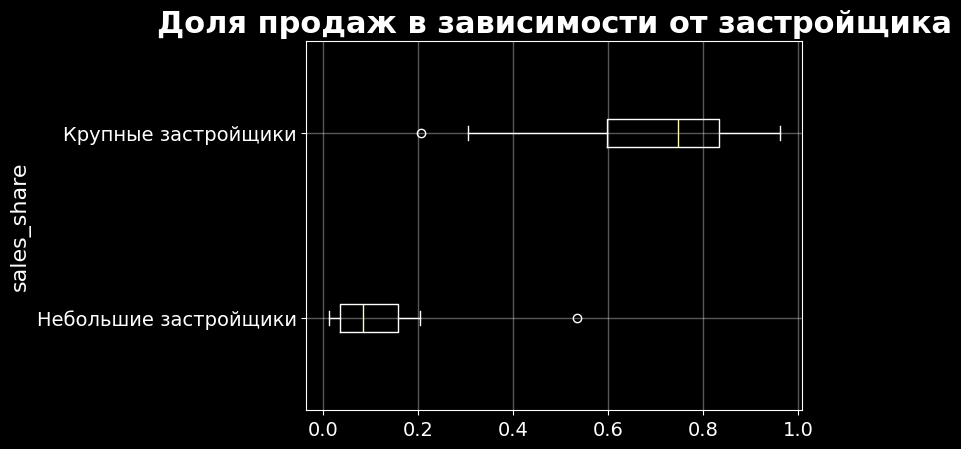

17.91304347826087

In [ ]:
buildings_group_df["size_group"] = (
    buildings_group_df["developer_total_buildings"] >= median_devs
).map({
    True: "Крупные застройщики",
    False: "Небольшие застройщики"
})

plt.figure(figsize=(8, 8))

data = [
    buildings_group_df.loc[
        buildings_group_df["size_group"] == "Небольшие застройщики",
        "sales_share"
    ],
    buildings_group_df.loc[
        buildings_group_df["size_group"] == "Крупные застройщики",
        "sales_share"
    ]
]

plt.figure()

plt.boxplot(
    data,
    vert=False,              # <-- горизонтально
    labels=["Небольшие застройщики", "Крупные застройщики"],
    showfliers=True,
)

plt.ylabel("sales_share")
plt.title("Доля продаж в зависимости от застройщика")
plt.show()

median_devs

In [84]:
import pandas as pd
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

def compare_groups_auto(
    df,
    value_col,
    group_col,
    group1,
    group2,
    alpha=0.05
):
    # --- выборки ---
    s1 = df.loc[df[group_col] == group1, value_col].dropna()
    s2 = df.loc[df[group_col] == group2, value_col].dropna()

    n1, n2 = len(s1), len(s2)

    # --- Shapiro (по данным) ---
    shapiro_p1 = shapiro(s1).pvalue if n1 >= 3 else None
    shapiro_p2 = shapiro(s2).pvalue if n2 >= 3 else None

    normal_1 = shapiro_p1 is not None and shapiro_p1 > alpha
    normal_2 = shapiro_p2 is not None and shapiro_p2 > alpha

    # --- Levene ---
    levene_p = levene(s1, s2).pvalue
    equal_var = levene_p > alpha

    # --- выбор теста ---
    if n1 < 30 or n2 < 30:
        if normal_1 and normal_2:
            test_name = "Student t-test" if equal_var else "Welch t-test"
        else:
            test_name = "Mann–Whitney U"
    else:
        test_name = "Student t-test" if equal_var else "Welch t-test"

    # --- запуск теста ---
    if test_name == "Student t-test":
        stat, p_value = ttest_ind(s1, s2, equal_var=True)
    elif test_name == "Welch t-test":
        stat, p_value = ttest_ind(s1, s2, equal_var=False)
    else:
        stat, p_value = mannwhitneyu(s1, s2, alternative="two-sided")

    # --- итоговый DataFrame ---
    result_df = pd.DataFrame({
        "metric": [
            "Group 1",
            "Group 2",
            "n (group 1)",
            "n (group 2)",
            "Shapiro p (group 1)",
            "Shapiro p (group 2)",
            "Normal (group 1)",
            "Normal (group 2)",
            "Levene p-value",
            "Equal variances",
            "Chosen test",
            "Test statistic",
            "p-value",
            "Statistically significant (α=0.05)"
        ],
        "value": [
            group1,
            group2,
            n1,
            n2,
            shapiro_p1,
            shapiro_p2,
            normal_1,
            normal_2,
            levene_p,
            equal_var,
            test_name,
            stat,
            p_value,
            p_value <= alpha
        ]
    })

    return result_df


assumptions_df = compare_groups_auto(
    df=buildings_group_df,
    value_col="sales_share",
    group_col="size_group",
    group1="Небольшие застройщики",
    group2="Крупные застройщики"
)

assumptions_df


,metric,value
0,Group 1,Небольшие застройщики
1,Group 2,Крупные застройщики
2,n (group 1),12
3,n (group 2),105
4,Shapiro p (group 1),0.002025
5,Shapiro p (group 2),0.000208
6,Normal (group 1),False
7,Normal (group 2),False
8,Levene p-value,0.160858
9,Equal variances,True


In [ ]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

def normal_means(s):
    choice_iterations = 1000000
    sample_size = 100
    shapiro_iterations = 25
    unique_elems = s.unique()
    arr = pd.Series([np.random.choice(unique_elems, len(s)).mean() for _ in range(choice_iterations)])
    return np.mean([shapiro(arr.sample(sample_size))[1] for _ in range(shapiro_iterations)])

def equal_var(*s):
    p_levene = levene(*s)[-1]
    if p_levene > 0.05:
        print('Дисперсии выборок равны')
    else:
        print('Дисперсии выборок равны') 
    return p_levene

def compare_mean(df, col1, col2):
    s1 = df[col1]
    s2 = df[col2]
    p_normal_means_s1 = normal_means(s1)
    p_normal_means_s12 = normal_means(s2)
    p_equal_var = equal_var(s1, s2)
    print('p_normal_means_s1:', p_normal_means_s1)
    print('p_normal_means_s12:', p_normal_means_s12)
    print('p_equal_var:', p_equal_var)
    if p_normal_means_s1 > 0.05 and p_normal_means_s12 > 0.05:
        if p_equal_var > 0.05:
            print('Т-Критерий Стьюдента')
            p_test = ttest_ind(s1, s2, equal_var=True)[-1]
        else:
            print('Т-Критерий Уэлча')
            p_test = ttest_ind(s1, s2, equal_var=False)[-1]
    else:
        print('U-критерий Манна-Уитни')
        p_test = mannwhitneyu(s1, s2)[-1]
    print('p-value:', p_test)
    if p_test <= 0.05:
        print('Средние стат. значимо отличаются')
    else:
        print('Средние стат. значимо НЕ отличаются')

compare_mean(buildings_group_df)

/var/folders/ws/lrvlpqj171xc51myg0jksgdr0000gn/T/ipykernel_17526/3115042967.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


<Figure size 800x800 with 0 Axes>

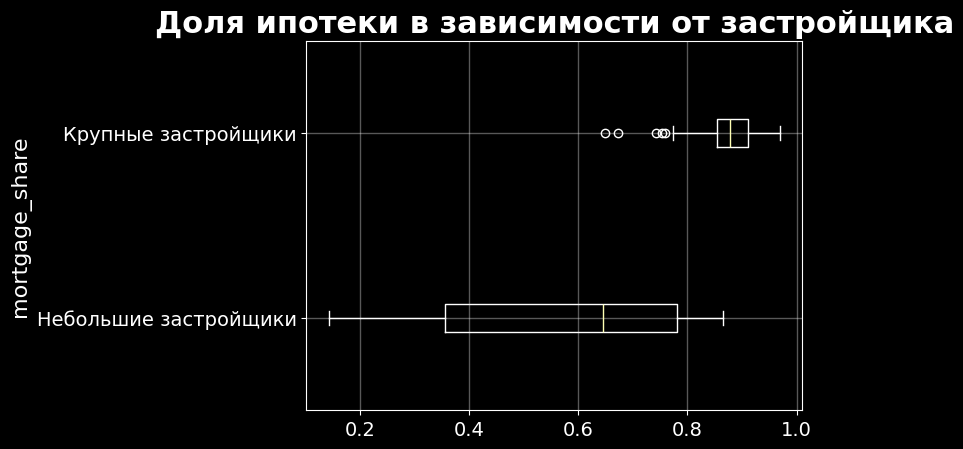

17.91304347826087

In [74]:
buildings_group_df["size_group"] = (
    buildings_group_df["developer_total_buildings"] >= median_devs
).map({
    True: "Крупные застройщики",
    False: "Небольшие застройщики"
})

plt.figure(figsize=(8, 8))

data = [
    buildings_group_df.loc[
        buildings_group_df["size_group"] == "Небольшие застройщики",
        "mortgage_share"
    ],
    buildings_group_df.loc[
        buildings_group_df["size_group"] == "Крупные застройщики",
        "mortgage_share"
    ]
]

plt.figure()

plt.boxplot(
    data,
    vert=False,              # <-- горизонтально
    labels=["Небольшие застройщики", "Крупные застройщики"],
    showfliers=True
)


plt.ylabel("mortgage_share")
plt.title("Доля ипотеки в зависимости от застройщика")
plt.show()

median_devs

In [62]:
district_size_stats = (
    buildings_group_df
    .groupby(["район", "size_group"])
    .agg(
        n=("id_корпуса", "count"),
        developer_buildings_count=("sales_share", "median"),
        sales_share_mean=("sales_share", "mean"),
        sales_share_median=("sales_share", "median"),
        sales_share_std=("sales_share", "std"),
        sales_share_min=("sales_share", "min"),
        sales_share_max=("sales_share", "max"),
    )
    .reset_index()
    .round(3)
)

district_size_stats

,район,size_group,n,developer_buildings_count,sales_share_mean,sales_share_median,sales_share_std,sales_share_min,sales_share_max
0,Внуково,Крупные застройщики,8,0.559,0.537,0.559,0.088,0.332,0.614
1,Внуково,Небольшие застройщики,4,0.187,0.265,0.187,0.180,0.154,0.534
2,Коммунарка,Крупные застройщики,74,0.764,0.720,0.764,0.179,0.207,0.961
3,Троицк,Крупные застройщики,3,0.770,0.767,0.770,0.011,0.755,0.776
4,Троицк,Небольшие застройщики,6,0.031,0.053,0.031,0.052,0.013,0.141
5,Филимонковский,Крупные застройщики,6,0.563,0.640,0.563,0.204,0.457,0.898
6,Филимонковский,Небольшие застройщики,2,0.079,0.079,0.079,0.002,0.077,0.080
7,Щербинка,Крупные застройщики,14,0.755,0.759,0.755,0.068,0.626,0.870


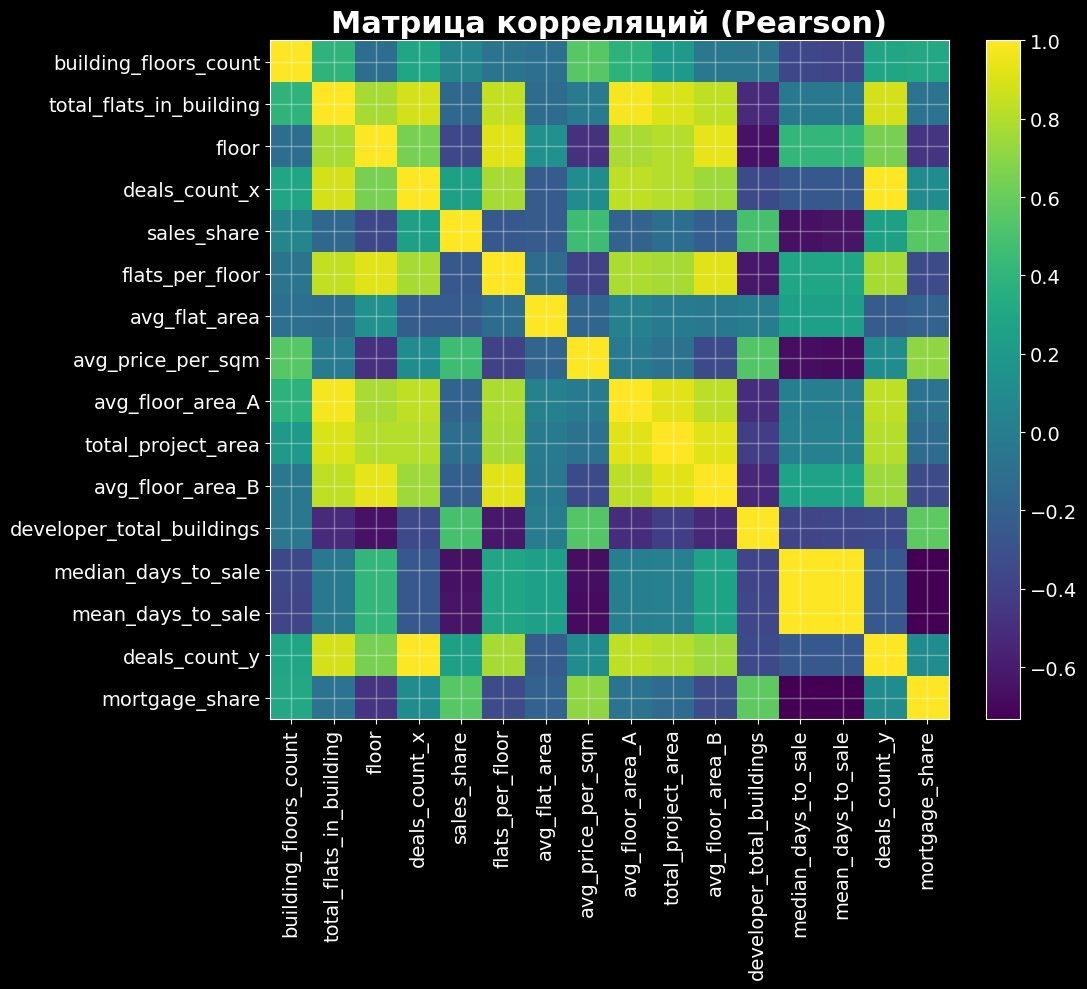

In [34]:
import numpy as np

numeric_df = buildings_group_df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr(method="pearson").round(3)
corr_matrix

plt.figure(figsize=(12, 10))

im = plt.imshow(corr_matrix)

plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns,
    rotation=90
)
plt.yticks(
    ticks=np.arange(len(corr_matrix.columns)),
    labels=corr_matrix.columns
)

plt.title("Матрица корреляций (Pearson)")
plt.tight_layout()
plt.show()

